## Irriducible Mass of BHs:

For a BH of mass $M$ and spin $\chi\in [0,1]$, the irreducible mass is 
$$ M_{\rm irr} = %\sqrt{\frac{M^2+\sqrt{M^4-S^2}}{2}} = 
 M \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}}$$
For convenience, let us define 

$$f(\chi) = \sqrt{\frac{1+\sqrt{1-\chi^2}}{2}} = \frac{M_{\rm irr}}{M}$$

Suppose you have repeated measurments of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

- the spin $\chi$ is uniformly distributed between 0 and 1.
- the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks**:

1. Start with a value of $\sigma=0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu=1$ in your code and remember that all masses in the problem are measured in units of $\mu$.
2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

In [1]:
from scipy import stats
from astropy.visualization.hist import hist as fancyhist
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KernelDensity

In [2]:
N = 10000 #Number of samples

def f(chi):
    f = ((1+(1-(chi**2))**0.5)*0.5)**0.5
    return f

In [3]:
chi = np.random.uniform(0,1,N)
fs = f(chi)

Text(0.5, 0, '$f(\\chi)$')

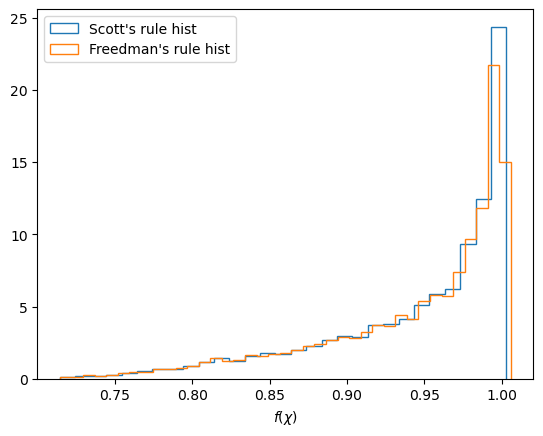

In [4]:
_ = fancyhist(fs, bins='scott', histtype = 'step', density = True, label = "Scott's rule hist")
_ = fancyhist(fs, bins='freedman', histtype = 'step', density = True, label = "Freedman's rule hist")
plt.legend()
plt.xlabel(r'$f(\chi)$')

Text(0.5, 0, '$M_{bh}\\:[\\mu]$')

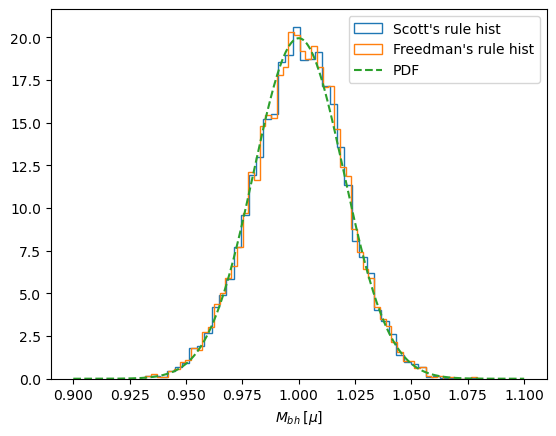

In [5]:
#Sampling the mass distribution
mu = 1.0
sigma = 0.02
mass = np.random.normal(loc = mu, scale = sigma, size = N)
x = np.linspace(mu-5*sigma, mu+5*sigma, N)
pdf = stats.norm.pdf(x, mu, sigma)

_ = fancyhist(mass, bins='scott', histtype = 'step', density = True, label = "Scott's rule hist")
_ = fancyhist(mass, bins='freedman', histtype = 'step', density = True, label = "Freedman's rule hist")
plt.plot(x, pdf, '--', label = 'PDF')
plt.legend()
plt.xlabel(r'$M_{bh}\:[\mu]$')

Text(0.5, 0, '$M_{irr}\\:[\\mu]$')

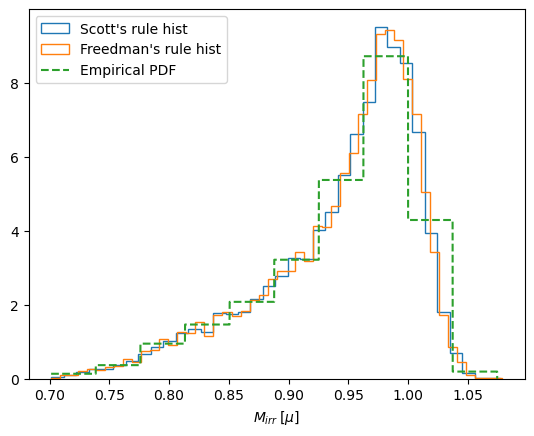

In [6]:
#Resulting pdf for the irr mass
irrm = fs * mass
hist_irrm = np.histogram(irrm, density = True)
pdf_irrm = stats.rv_histogram(hist_irrm)
x = np.linspace(irrm.min(), irrm.max(), N)

_ = fancyhist(irrm, bins='scott', histtype = 'step', density = True, label = "Scott's rule hist")
_ = fancyhist(irrm, bins='freedman', histtype = 'step', density = True, label = "Freedman's rule hist")
plt.plot(x, pdf_irrm.pdf(x), '--', label='Empirical PDF')
plt.legend()
plt.xlabel(r'$M_{irr}\:[\mu]$')

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.

In [7]:
grid = np.linspace(irrm.min(), irrm.max(),1000)

def kde_sklearn(data, bandwidth = 0.05, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(grid[:, np.newaxis]) #sklearn returns log(density)

    return np.exp(log_pdf)

Text(0.5, 0, '$M_{irr}$')

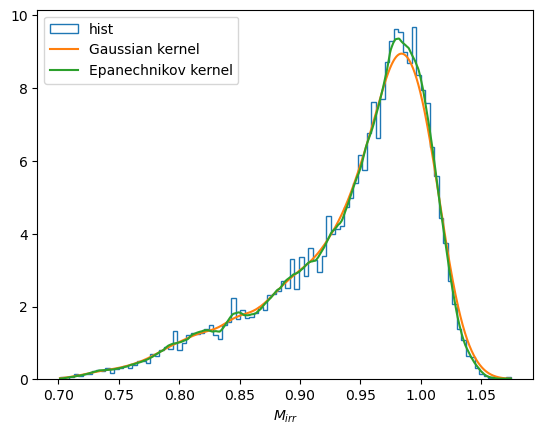

In [8]:
KDE_gauss = kde_sklearn(irrm,bandwidth=0.01,kernel="gaussian")
KDE_epa = kde_sklearn(irrm,bandwidth=0.01,kernel="epanechnikov") 


plt.hist(irrm, density = True, bins = 100, label = 'hist', histtype = 'step')
plt.plot(grid, KDE_gauss, label = 'Gaussian kernel')
plt.plot(grid, KDE_epa, label = 'Epanechnikov kernel')
plt.legend()
plt.xlabel(r'$M_{irr}$')

4. Compute the KS distance between ${M_{\rm irr}}$ and ${f}$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$. 

5. Compute the KS distance between ${M_{\rm irr}}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

In [9]:
def irrm_sigma(sigma):
    mass = np.random.normal(loc = mu, scale = sigma, size = N)
    chi = np.random.uniform(0,1,N)
    fs = f(chi)
    m_irr = mass*fs
    return m_irr

Text(0.5, 0, '$M_{irr}$')

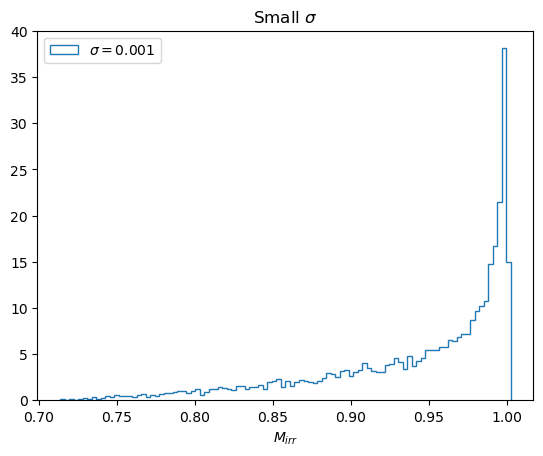

In [10]:
small_s = irrm_sigma(0.001)
big_s = irrm_sigma(1.0)

plt.title(r'Small $\sigma$')
plt.hist(small_s, bins = 100, density = True, histtype = 'step', label = r'$\sigma = 0.001$')
plt.legend()
plt.xlabel(r'$M_{irr}$')

Text(0.5, 0, '$M_{irr}$')

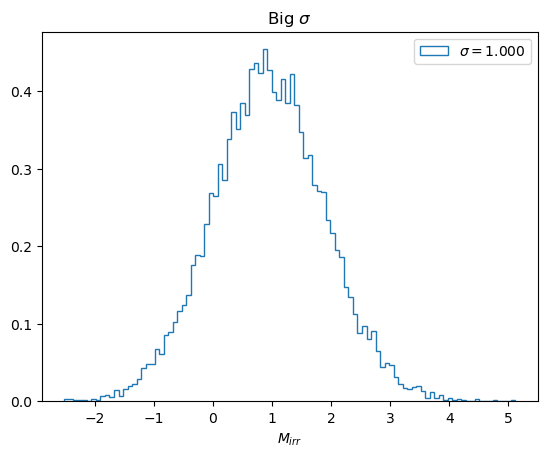

In [11]:
plt.hist(big_s, bins = 100, density = True, histtype = 'step', label = r'$\sigma = 1.000$')
plt.legend()
plt.title(r'Big $\sigma$')
plt.xlabel(r'$M_{irr}$')

In [12]:
N_sigma = 10
sigmas = np.linspace(0.001, 15, N_sigma)
KSirr = []
KSm = []

chi = np.random.uniform(0,1,N)
fs2 = f(chi)
for i in sigmas:
    M = np.random.normal(loc=mu, scale = i, size = N)
    KSirr.append(stats.ks_2samp(M, M*fs2))
    KSm.append(stats.ks_2samp(fs, M*fs2))

KSirr = np.array(KSirr)
KSm = np.array(KSm)

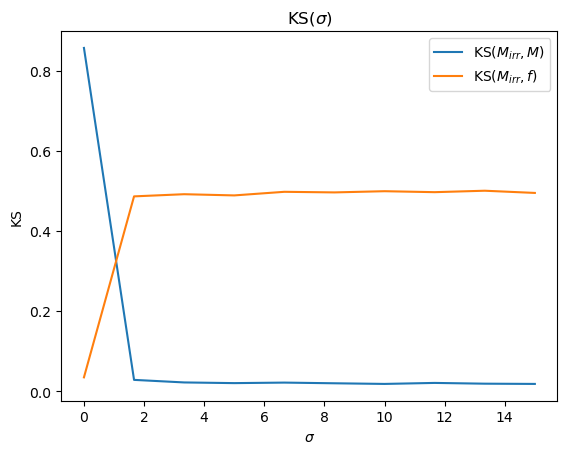

In [13]:
plt.plot(sigmas, KSirr[:,0], label = r'KS($M_{irr}, M$)')
plt.plot(sigmas, KSm[:,0], label = r'KS($M_{irr}, f$)')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS')
plt.title(r'KS($\sigma$)')
plt.legend()

As a small KS implies that the distributions of the two samples are similar, we have that for small $\sigma$, $M_{irr}$ is distributed as f, while for bigger $\sigma$ it follows the same distribution of M.

6. You should find that (i) $M_{\rm irr}$ is distributed like $f$ if ${\sigma}\ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if  $\sigma\gg \mu$.

Let's check with our previous result first!

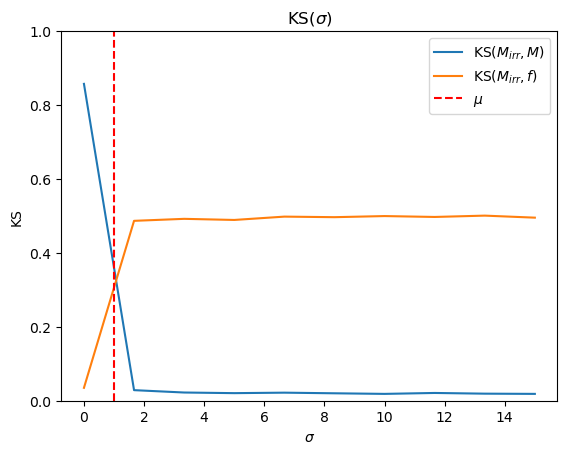

In [14]:
plt.plot(sigmas, KSirr[:,0], label = r'KS($M_{irr}, M$)')
plt.plot(sigmas, KSm[:,0], label = r'KS($M_{irr}, f$)')
plt.vlines(mu, 0, 1, label = r'$\mu$', color = 'red', linestyle = '--')
plt.xlabel(r'$\sigma$')
plt.ylabel('KS')
plt.title(r'KS($\sigma$)')
plt.ylim(0,1)
plt.legend()

Ok it does follow what we said earlier!

7. Compute the pdfs of $M_{\rm irr}$ from their mathematical definitions, plot them, and check they agree with your KDE.

Following the theorem for the product of two random variables, we find:

$ p(M_{irr})  = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[{-\frac{(M_{irr}/f -\mu)^2}{2\sigma^2}}\right]  \frac{2 f^2-1}{f \sqrt{1 - f^2}}  \,\, {\rm d}f\,. $

This has to be solved numerically! Let's try it:

In [15]:
chi = np.random.uniform(0, 1, N)
fs = f(chi)
mu = 1.0
sigma = 0.02
mass = np.random.normal(loc = mu, scale = sigma, size = N)
mirr = fs*mass
x = np.linspace(mu-15*sigma, mu+5*sigma, N)

from scipy import integrate

def integrand(f,x):
    return ((2/np.pi)**0.5 /sigma) * np.exp(-(x/f-mu)**2 /(2*sigma**2)) * (2*f**2-1)/(1-f**2)**0.5 /f    

In [16]:
pdf = [integrate.quad(lambda fs: integrand(fs,i), 1/2**0.5,1)[0] for i in x]

Text(0.5, 0, '$M_{irr}$')

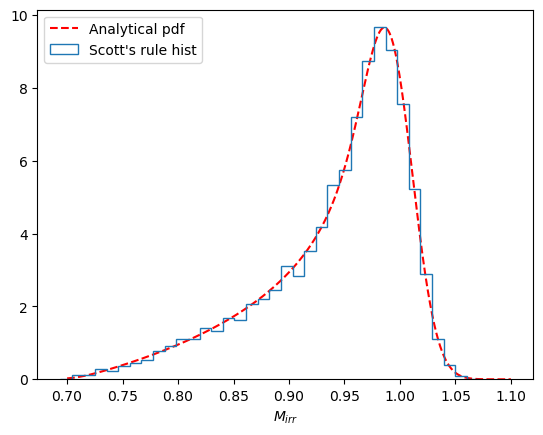

In [17]:
plt.plot(x, pdf, '--r', label = 'Analytical pdf')
_ = fancyhist(mirr, bins='scott', histtype = 'step', density = True, label = "Scott's rule hist")
plt.legend()
plt.xlabel(r'$M_{irr}$')

Let's compare it with our KDE with the Epanechnikov kernel with different bandwidths:

Text(0.5, 0, '$M_{irr}$')

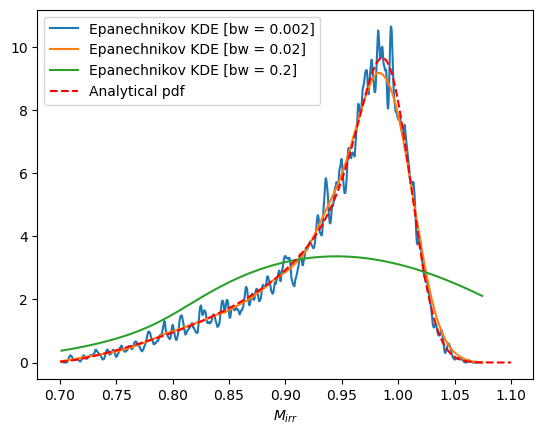

In [18]:
bw = [0.002, 0.02, 0.2]
KDE_epa = [kde_sklearn(mirr,bandwidth=i,kernel="epanechnikov") for i in bw]

for i in range(len(bw)):
    plt.plot(grid, KDE_epa[i], label = f'Epanechnikov KDE [bw = {bw[i]}]')
plt.plot(x, pdf, '--r', label = 'Analytical pdf')
plt.legend()
plt.xlabel(r'$M_{irr}$')

With the right bandwidth our KDE is very similar to the analytical solution!